# Experiment 2 — Sparse Architectural Constraints

Visualization-only notebook. All heavy compute runs on Modal; this notebook loads JSON/npz artifacts.

**Two approaches tested:**
- **L1 activation penalty** (soft): L1 on post-GELU d_ff hidden activations at λ=1e-4/1e-3/1e-2
- **Top-K MLP** (hard): zero all-but-top-k neurons per token at k=10%/25%/50% of d_ff=1536

## Download artifacts first

```bash
# Baseline (from Experiment 1)
modal volume get tti-checkpoints eval/expt1_baseline_seed42/ checkpoints/eval/expt1_baseline_seed42/

# L1 runs
modal volume get tti-checkpoints eval/expt2_l1_1e-4_seed42/ checkpoints/eval/expt2_l1_1e-4_seed42/
modal volume get tti-checkpoints eval/expt2_l1_1e-3_seed42/ checkpoints/eval/expt2_l1_1e-3_seed42/
modal volume get tti-checkpoints eval/expt2_l1_1e-2_seed42/ checkpoints/eval/expt2_l1_1e-2_seed42/

# Top-K runs
modal volume get tti-checkpoints eval/expt2_topk_10pct_seed42/ checkpoints/eval/expt2_topk_10pct_seed42/
modal volume get tti-checkpoints eval/expt2_topk_25pct_seed42/ checkpoints/eval/expt2_topk_25pct_seed42/
modal volume get tti-checkpoints eval/expt2_topk_50pct_seed42/ checkpoints/eval/expt2_topk_50pct_seed42/
```

Local deps:
```bash
pip install matplotlib seaborn pandas
```

In [1]:
import json
import os

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import pandas as pd
import seaborn as sns

ARTIFACT_DIR = "../checkpoints/eval"

RUN_NAMES = [
    "expt1_baseline_seed42",
    "expt2_l1_1e-4_seed42",
    "expt2_l1_1e-3_seed42",
    "expt2_l1_1e-2_seed42",
    "expt2_topk_10pct_seed42",
    "expt2_topk_25pct_seed42",
    "expt2_topk_50pct_seed42",
]
RUN_LABELS = {
    "expt1_baseline_seed42":    "Baseline",
    "expt2_l1_1e-4_seed42":     "L1 λ=1e-4",
    "expt2_l1_1e-3_seed42":     "L1 λ=1e-3",
    "expt2_l1_1e-2_seed42":     "L1 λ=1e-2",
    "expt2_topk_10pct_seed42":  "Top-K 10%",
    "expt2_topk_25pct_seed42":  "Top-K 25%",
    "expt2_topk_50pct_seed42":  "Top-K 50%",
}
# Grey baseline; green gradient for L1; purple gradient for Top-K
RUN_COLORS = {
    "expt1_baseline_seed42":    "#555555",
    "expt2_l1_1e-4_seed42":     "#74c476",
    "expt2_l1_1e-3_seed42":     "#31a354",
    "expt2_l1_1e-2_seed42":     "#006d2c",
    "expt2_topk_10pct_seed42":  "#9e9ac8",
    "expt2_topk_25pct_seed42":  "#756bb1",
    "expt2_topk_50pct_seed42":  "#54278f",
}
RUN_LINESTYLES = {
    "expt1_baseline_seed42":    "--",
    "expt2_l1_1e-4_seed42":     "-",
    "expt2_l1_1e-3_seed42":     "-",
    "expt2_l1_1e-2_seed42":     "-",
    "expt2_topk_10pct_seed42":  "-",
    "expt2_topk_25pct_seed42":  "-",
    "expt2_topk_50pct_seed42":  "-",
}
N_LAYERS = 6


def artifact_path(run_name, filename):
    return os.path.join(ARTIFACT_DIR, run_name, filename)

def load_json(run_name, filename):
    with open(artifact_path(run_name, filename)) as f:
        return json.load(f)

def load_npz(run_name, filename):
    return np.load(artifact_path(run_name, filename))

def has_artifact(run_name, filename):
    return os.path.exists(artifact_path(run_name, filename))


AVAILABLE_RUNS = [r for r in RUN_NAMES if has_artifact(r, "perplexity.json")]
print(f"Available runs ({len(AVAILABLE_RUNS)}/{len(RUN_NAMES)}):")
for r in AVAILABLE_RUNS:
    print(f"  {RUN_LABELS[r]}")

Available runs (7/7):
  Baseline
  L1 λ=1e-4
  L1 λ=1e-3
  L1 λ=1e-2
  Top-K 10%
  Top-K 25%
  Top-K 50%


## 1. Perplexity

Key question: does enforcing sparsity hurt language modelling quality?

,Val Loss,Perplexity
Run,,
Baseline,1.4598,4.31
L1 λ=1e-4,1.4599,4.31
L1 λ=1e-3,1.4600,4.31
L1 λ=1e-2,1.4601,4.31
Top-K 10%,1.4899,4.44
Top-K 25%,1.4869,4.42
Top-K 50%,1.4806,4.40


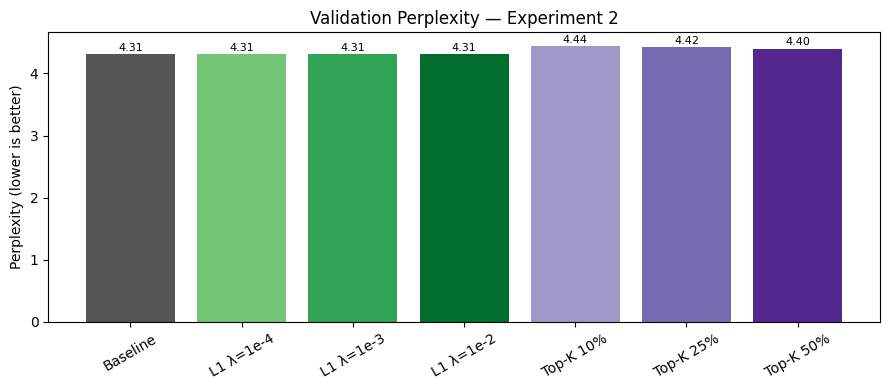

In [2]:
rows = []
for run_name in AVAILABLE_RUNS:
    data = load_json(run_name, "perplexity.json")
    rows.append({
        "Run": RUN_LABELS[run_name],
        "Val Loss": f"{data['val_loss']:.4f}",
        "Perplexity": f"{data['perplexity']:.2f}",
    })

df = pd.DataFrame(rows).set_index("Run")
display(df)

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
vals = [float(r["Perplexity"]) for r in rows]
colors = [RUN_COLORS[r] for r in AVAILABLE_RUNS]
bars = ax.bar([RUN_LABELS[r] for r in AVAILABLE_RUNS], vals, color=colors)
ax.set_ylabel("Perplexity (lower is better)")
ax.set_title("Validation Perplexity — Experiment 2")
ax.tick_params(axis="x", rotation=30)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f"{v:.2f}",
            ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

## 2. Activation Sparsity

Fraction of d_ff hidden neurons with |activation| < 0.01, per layer.

- **Top-K runs**: sparsity is exact by construction (10%/25%/50% zeroed = 90%/75%/50% inactive)
- **L1 runs**: soft sparsity — fraction depends on how much the penalty pushes activations to zero
- **Baseline**: near-zero from GELU, but no pressure

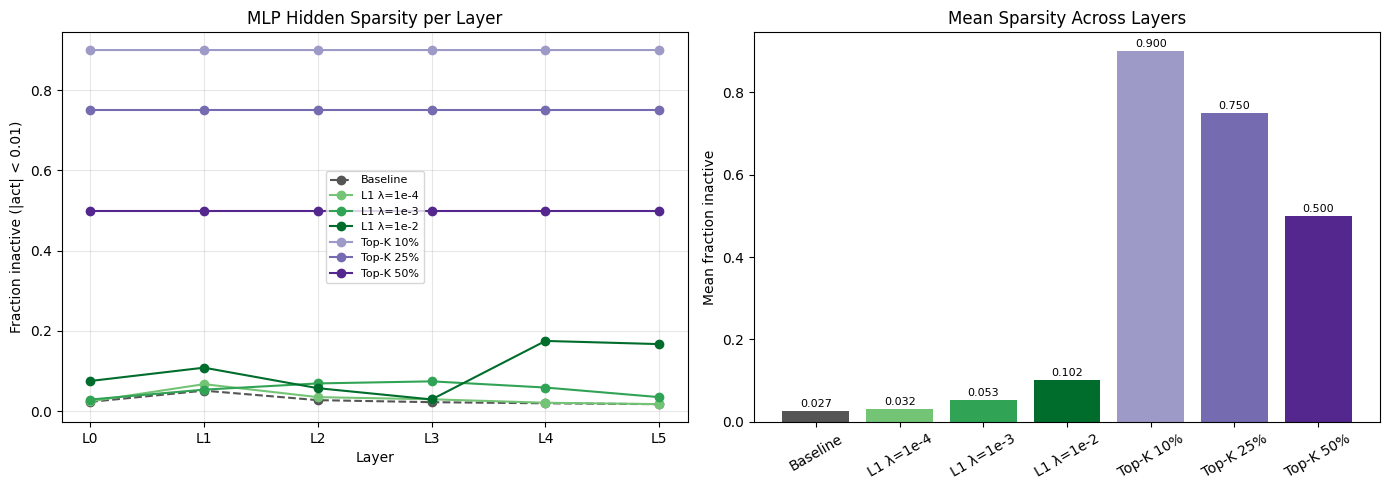

,Mean,L0,L1,L2,L3,L4,L5
Run,,,,,,,
Baseline,0.027,0.023,0.051,0.027,0.022,0.019,0.017
L1 λ=1e-4,0.032,0.024,0.067,0.035,0.029,0.021,0.017
L1 λ=1e-3,0.053,0.029,0.053,0.069,0.074,0.059,0.035
L1 λ=1e-2,0.102,0.075,0.108,0.057,0.029,0.175,0.167
Top-K 10%,0.900,0.900,0.900,0.900,0.900,0.900,0.900
Top-K 25%,0.750,0.750,0.750,0.750,0.750,0.750,0.750
Top-K 50%,0.500,0.500,0.500,0.500,0.500,0.500,0.500


In [3]:
sparsity_runs = [r for r in AVAILABLE_RUNS if has_artifact(r, "sparsity.json")]

if not sparsity_runs:
    print("No sparsity.json artifacts found yet. Run eval_main first.")
else:
    sparsity_data = {r: load_json(r, "sparsity.json") for r in sparsity_runs}

    # --- Line chart: sparsity per layer ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for run_name in sparsity_runs:
        d = sparsity_data[run_name]
        layers = list(range(N_LAYERS))
        vals = [d.get(f"layer_{i}", 0) for i in layers]
        kw = dict(
            marker="o",
            label=RUN_LABELS[run_name],
            color=RUN_COLORS[run_name],
            linestyle=RUN_LINESTYLES[run_name],
        )
        axes[0].plot(layers, vals, **kw)

    axes[0].set_xlabel("Layer")
    axes[0].set_ylabel("Fraction inactive (|act| < 0.01)")
    axes[0].set_title("MLP Hidden Sparsity per Layer")
    axes[0].set_xticks(range(N_LAYERS))
    axes[0].set_xticklabels([f"L{i}" for i in range(N_LAYERS)])
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3)

    # --- Bar chart: mean sparsity ---
    means = [sparsity_data[r]["mean"] for r in sparsity_runs]
    colors = [RUN_COLORS[r] for r in sparsity_runs]
    bars = axes[1].bar([RUN_LABELS[r] for r in sparsity_runs], means, color=colors)
    axes[1].set_ylabel("Mean fraction inactive")
    axes[1].set_title("Mean Sparsity Across Layers")
    axes[1].tick_params(axis="x", rotation=30)
    for bar, v in zip(bars, means):
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                     f"{v:.3f}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    plt.show()

    # Summary table
    rows = []
    for run_name in sparsity_runs:
        d = sparsity_data[run_name]
        row = {"Run": RUN_LABELS[run_name], "Mean": f"{d['mean']:.3f}"}
        for i in range(N_LAYERS):
            row[f"L{i}"] = f"{d.get(f'layer_{i}', 0):.3f}"
        rows.append(row)
    display(pd.DataFrame(rows).set_index("Run"))

## 3. Polysemanticity

Per-neuron entropy of the token-type activation distribution (measured on mlp_hidden).

- **High entropy** = neuron responds to many different token types → **polysemantic**
- **Low entropy** = neuron responds consistently to a narrow set of tokens → **monosemantic**

L1 counterintuitively *increases* polysemanticity by spreading activation budget across more tokens. Top-K enforces selectivity, driving neurons toward monosemanticity.

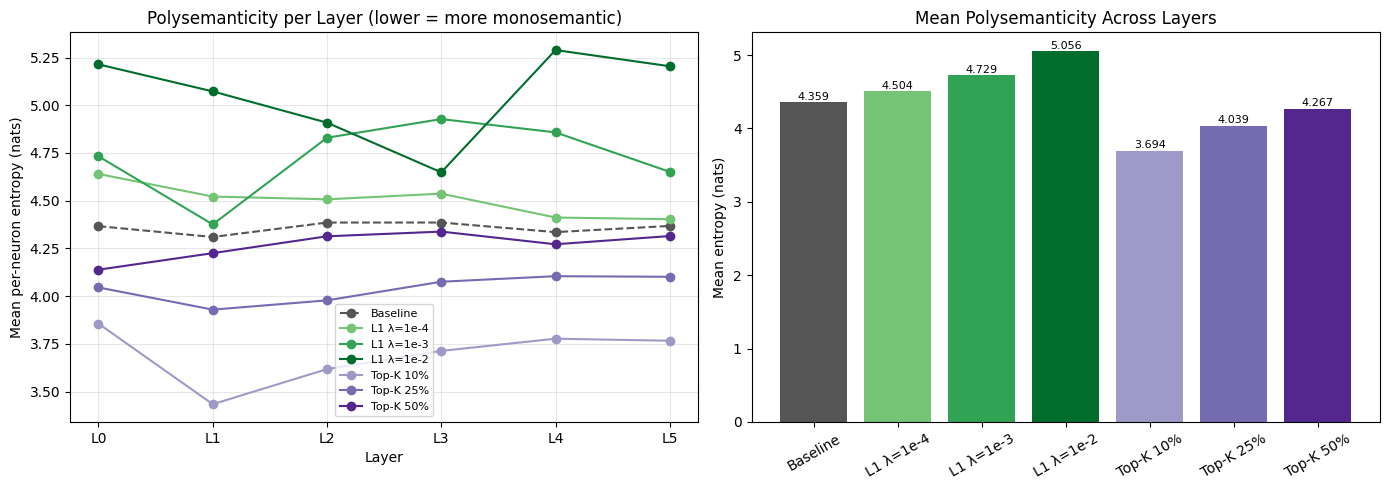

,Mean,L0,L1,L2,L3,L4,L5
Run,,,,,,,
Baseline,4.359,4.367,4.310,4.386,4.386,4.335,4.368
L1 λ=1e-4,4.504,4.640,4.522,4.507,4.537,4.412,4.403
L1 λ=1e-3,4.729,4.733,4.376,4.830,4.928,4.858,4.651
L1 λ=1e-2,5.056,5.214,5.073,4.909,4.649,5.289,5.204
Top-K 10%,3.694,3.856,3.434,3.618,3.713,3.777,3.767
Top-K 25%,4.039,4.046,3.930,3.978,4.076,4.105,4.102
Top-K 50%,4.267,4.139,4.225,4.314,4.338,4.272,4.315



Change vs baseline (%):
  L1 λ=1e-4             +3.3%
  L1 λ=1e-3             +8.5%
  L1 λ=1e-2             +16.0%
  Top-K 10%             -15.2%
  Top-K 25%             -7.3%
  Top-K 50%             -2.1%


In [4]:
poly_runs = [r for r in AVAILABLE_RUNS if has_artifact(r, "polysemanticity.json")]

if not poly_runs:
    print("No polysemanticity.json artifacts found. Run eval_main first.")
else:
    poly_data = {r: load_json(r, "polysemanticity.json") for r in poly_runs}

    # --- Line chart: entropy per layer ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for run_name in poly_runs:
        d = poly_data[run_name]
        layers = list(range(N_LAYERS))
        vals = [d.get(f"layer_{i}", 0) for i in layers]
        axes[0].plot(
            layers, vals,
            marker="o",
            label=RUN_LABELS[run_name],
            color=RUN_COLORS[run_name],
            linestyle=RUN_LINESTYLES[run_name],
        )

    axes[0].set_xlabel("Layer")
    axes[0].set_ylabel("Mean per-neuron entropy (nats)")
    axes[0].set_title("Polysemanticity per Layer (lower = more monosemantic)")
    axes[0].set_xticks(range(N_LAYERS))
    axes[0].set_xticklabels([f"L{i}" for i in range(N_LAYERS)])
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3)

    # --- Bar chart: mean polysemanticity ---
    means = [poly_data[r]["mean"] for r in poly_runs]
    colors = [RUN_COLORS[r] for r in poly_runs]
    bars = axes[1].bar([RUN_LABELS[r] for r in poly_runs], means, color=colors)
    axes[1].set_ylabel("Mean entropy (nats)")
    axes[1].set_title("Mean Polysemanticity Across Layers")
    axes[1].tick_params(axis="x", rotation=30)
    for bar, v in zip(bars, means):
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                     f"{v:.3f}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    plt.show()

    # Summary table
    rows = []
    for run_name in poly_runs:
        d = poly_data[run_name]
        row = {"Run": RUN_LABELS[run_name], "Mean": f"{d['mean']:.3f}"}
        for i in range(N_LAYERS):
            row[f"L{i}"] = f"{d.get(f'layer_{i}', 0):.3f}"
        rows.append(row)
    display(pd.DataFrame(rows).set_index("Run"))

    # --- Delta vs baseline ---
    if "expt1_baseline_seed42" in poly_data:
        base = poly_data["expt1_baseline_seed42"]
        print("\nChange vs baseline (%):")
        for run_name in poly_runs:
            if run_name == "expt1_baseline_seed42":
                continue
            delta = (poly_data[run_name]["mean"] - base["mean"]) / (base["mean"] + 1e-10) * 100
            sign = "+" if delta > 0 else ""
            print(f"  {RUN_LABELS[run_name]:20s}  {sign}{delta:.1f}%")

## 4. Neuron Utilization

For each neuron, what fraction of tokens does it activate on (|act| > 0.01)?

- **Dead neurons** (< 1% of tokens): wasted capacity
- **Always-on neurons** (> 99% of tokens): no selectivity — effectively a bias term
- **Selective neurons** (1–99%): doing meaningful work

Top-K should eliminate always-on neurons by construction (forced off for low-magnitude tokens). L1 may create dead neurons if the penalty pushes activations to zero everywhere.

,L0 dead%,L0 on%,L1 dead%,L1 on%,L2 dead%,L2 on%,L3 dead%,L3 on%,L4 dead%,L4 on%,L5 dead%,L5 on%
Run,,,,,,,,,,,,
Baseline,0.0,63.3,0.0,26.6,0.0,18.9,0.0,12.9,0.0,11.1,0.0,18.0
L1 λ=1e-4,0.0,54.4,0.0,20.4,0.0,17.8,0.0,13.3,0.0,11.1,0.0,16.6
L1 λ=1e-3,0.0,42.5,0.0,25.5,0.0,15.3,0.0,10.5,0.0,6.4,0.0,7.4
L1 λ=1e-2,0.0,22.7,0.0,10.0,0.0,6.5,0.0,13.9,0.0,2.9,0.0,0.3
Top-K 10%,0.1,0.0,4.6,0.0,0.5,0.0,0.2,0.0,0.0,0.0,0.1,0.0
Top-K 25%,0.0,0.0,1.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Top-K 50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


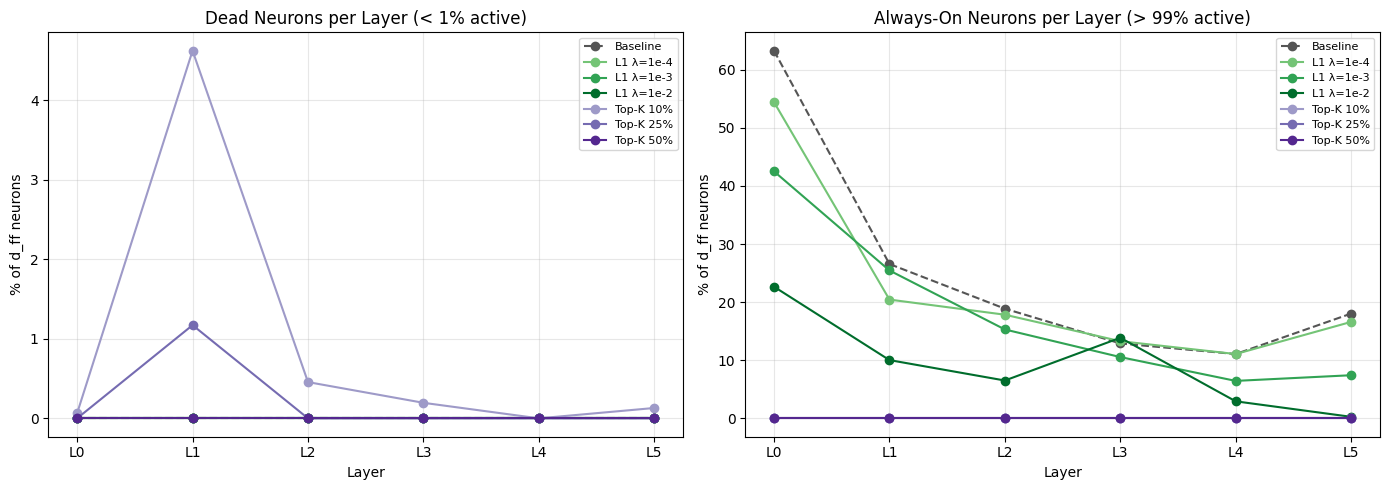

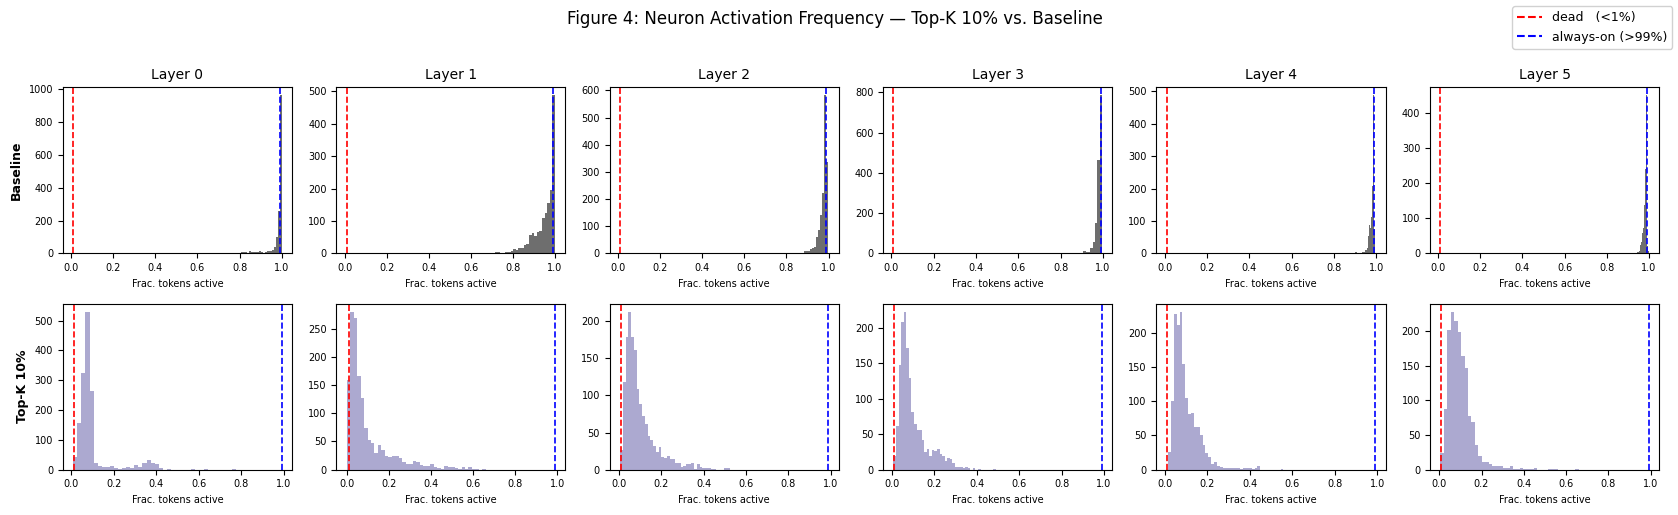

Saved fig4_neuron_utilization_topk_vs_baseline.jpg


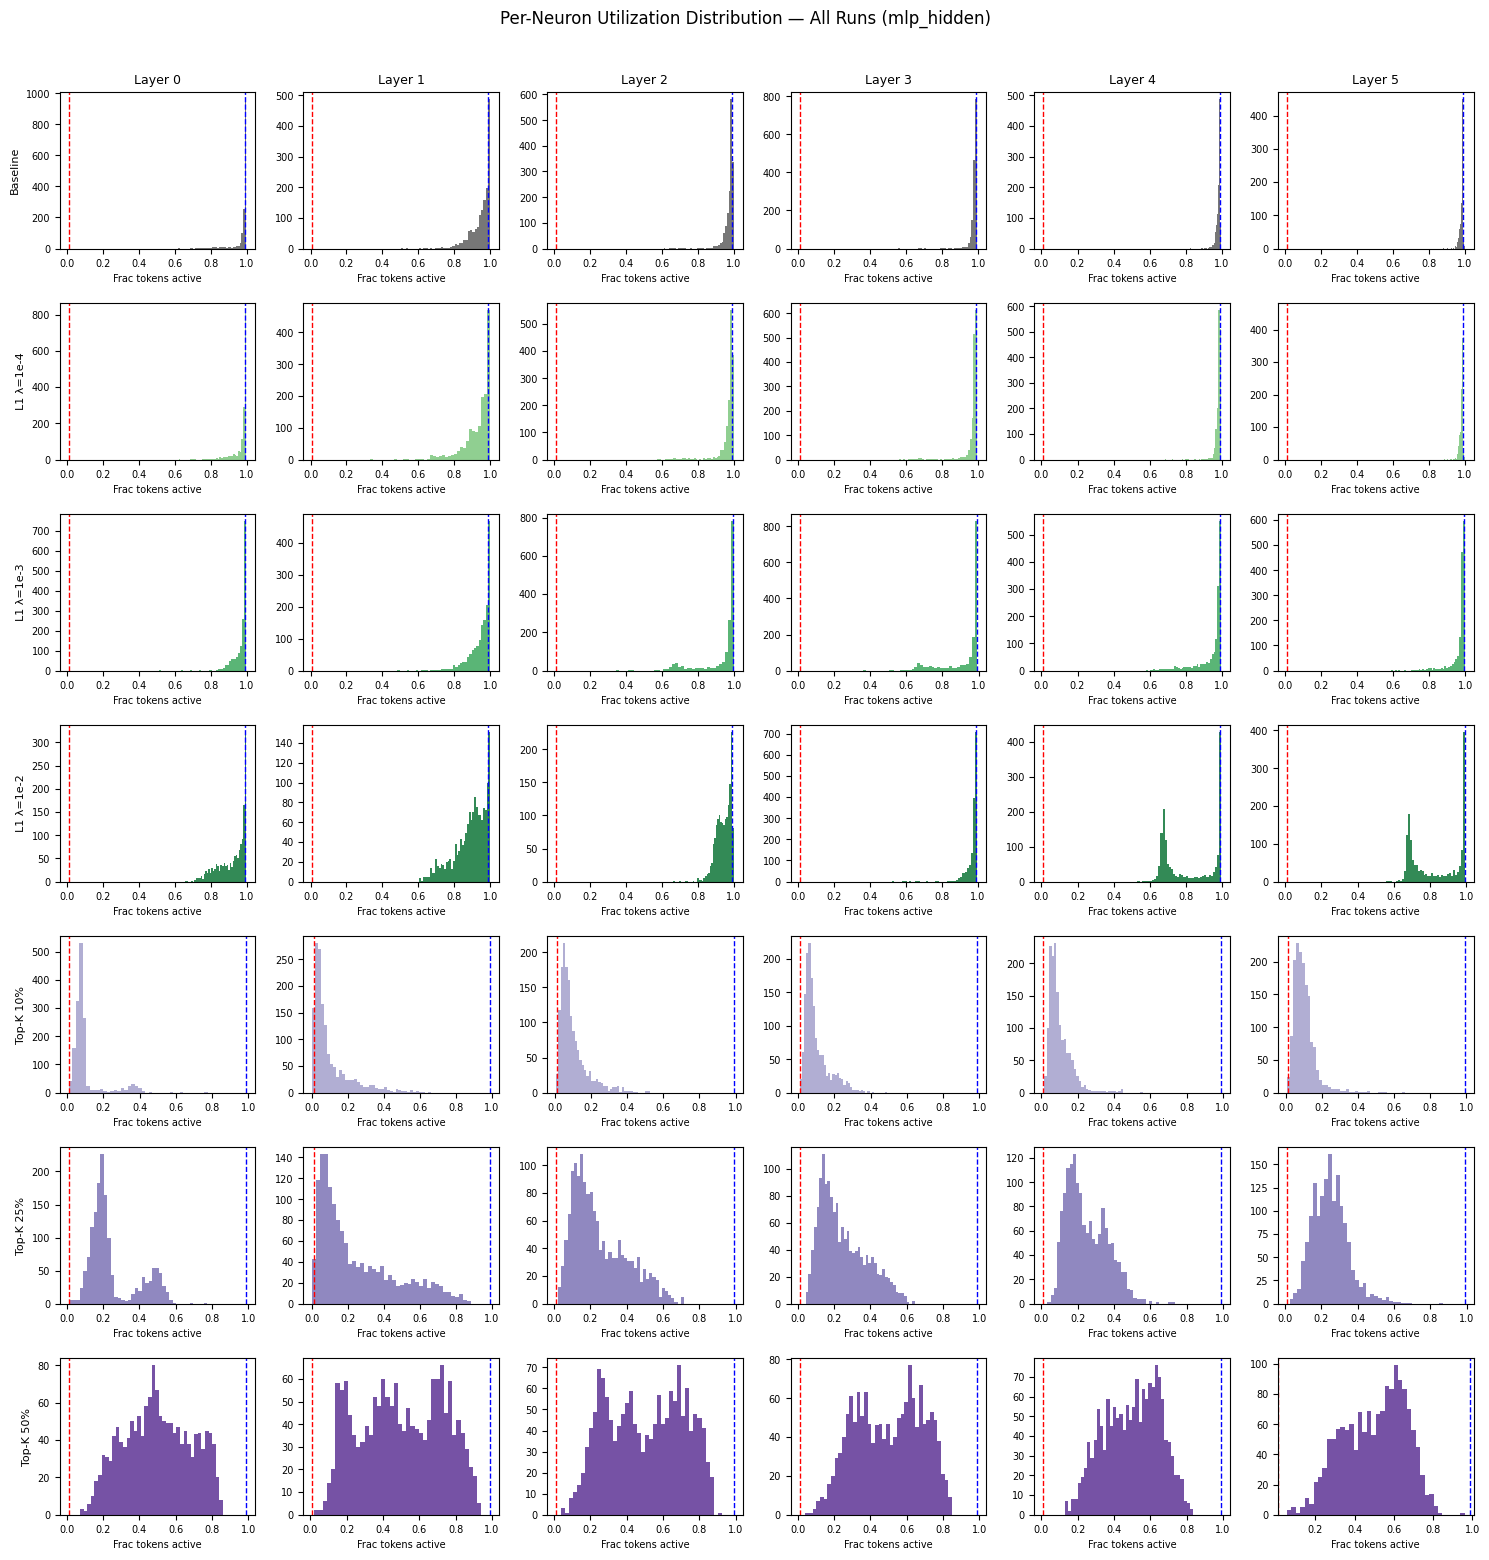

In [18]:
import os; os.makedirs("../figures", exist_ok=True)

util_runs = [r for r in AVAILABLE_RUNS if has_artifact(r, "neuron_utilization.json")]

if not util_runs:
    print("No neuron_utilization.json found. Run eval_main first.")
else:
    util_data = {r: load_json(r, "neuron_utilization.json") for r in util_runs}

    # --- Summary table (keys are "layer_0", "layer_1", ...) ---
    rows = []
    for run_name in util_runs:
        d = util_data[run_name]
        row = {"Run": RUN_LABELS[run_name]}
        for i in range(N_LAYERS):
            key = f"layer_{i}"
            if key in d:
                row[f"L{i} dead%"]  = f"{d[key]['frac_dead']*100:.1f}"
                row[f"L{i} on%"]    = f"{d[key]['frac_always_on']*100:.1f}"
        rows.append(row)
    display(pd.DataFrame(rows).set_index("Run"))

    # --- Dead & always-on line charts (all runs) ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for run_name in util_runs:
        d = util_data[run_name]
        layers    = [i for i in range(N_LAYERS) if f"layer_{i}" in d]
        dead_vals = [d[f"layer_{i}"]["frac_dead"]      * 100 for i in layers]
        alwon_vals= [d[f"layer_{i}"]["frac_always_on"] * 100 for i in layers]
        kw = dict(marker="o", label=RUN_LABELS[run_name],
                  color=RUN_COLORS[run_name], linestyle=RUN_LINESTYLES[run_name])
        axes[0].plot(layers, dead_vals,   **kw)
        axes[1].plot(layers, alwon_vals,  **kw)

    for ax, title, ylabel in zip(
        axes,
        ["Dead Neurons per Layer (< 1% active)", "Always-On Neurons per Layer (> 99% active)"],
        ["% of d_ff neurons", "% of d_ff neurons"],
    ):
        ax.set_xlabel("Layer"); ax.set_ylabel(ylabel); ax.set_title(title)
        ax.set_xticks(range(N_LAYERS)); ax.set_xticklabels([f"L{i}" for i in range(N_LAYERS)])
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Figure 4: per-neuron utilization histograms — TopK 10% vs Baseline ---
    fig4_runs = [r for r in ["expt1_baseline_seed42", "expt2_topk_10pct_seed42"]
                 if r in util_runs and has_artifact(r, "neuron_utilization.npz")]

    if fig4_runs:
        fig, axes = plt.subplots(len(fig4_runs), N_LAYERS,
                                 figsize=(N_LAYERS * 2.8, len(fig4_runs) * 2.5),
                                 squeeze=False)
        for row_idx, run_name in enumerate(fig4_runs):
            npz = load_npz(run_name, "neuron_utilization.npz")
            for col_idx in range(N_LAYERS):
                ax = axes[row_idx][col_idx]
                key = f"layer_{col_idx}"
                if key not in npz.files:
                    ax.axis("off"); continue
                frac = npz[key]
                ax.hist(frac, bins=40, color=RUN_COLORS[run_name], alpha=0.85, edgecolor="none")
                ax.axvline(0.01, color="red",  linewidth=1.2, linestyle="--")
                ax.axvline(0.99, color="blue", linewidth=1.2, linestyle="--")
                if col_idx == 0:
                    ax.set_ylabel(RUN_LABELS[run_name], fontsize=9, fontweight="bold")
                if row_idx == 0:
                    ax.set_title(f"Layer {col_idx}", fontsize=10)
                ax.set_xlabel("Frac. tokens active", fontsize=7)
                ax.tick_params(labelsize=7)

        # Shared legend
        import matplotlib.lines as mlines
        legend_handles = [
            mlines.Line2D([], [], color="red",  linestyle="--", label="dead   (<1%)"),
            mlines.Line2D([], [], color="blue", linestyle="--", label="always-on (>99%)"),
        ]
        fig.legend(handles=legend_handles, loc="upper right", fontsize=9, framealpha=0.9)
        fig.suptitle("Figure 4: Neuron Activation Frequency — Top-K 10% vs. Baseline",
                     fontsize=12, y=1.02)
        plt.tight_layout()
        plt.savefig("../figures/fig4_neuron_utilization_topk_vs_baseline.jpg",
                    dpi=300, bbox_inches="tight")
        plt.show()
        print("Saved fig4_neuron_utilization_topk_vs_baseline.jpg")

    # --- Full grid for all runs (exploratory) ---
    npz_runs = [r for r in util_runs if has_artifact(r, "neuron_utilization.npz")]
    if npz_runs:
        fig, axes = plt.subplots(len(npz_runs), N_LAYERS,
                                 figsize=(N_LAYERS * 2.5, len(npz_runs) * 2.2),
                                 squeeze=False)
        for row_idx, run_name in enumerate(npz_runs):
            npz = load_npz(run_name, "neuron_utilization.npz")
            for col_idx in range(N_LAYERS):
                ax = axes[row_idx][col_idx]
                key = f"layer_{col_idx}"
                if key not in npz.files:
                    ax.axis("off"); continue
                frac = npz[key]
                ax.hist(frac, bins=40, color=RUN_COLORS[run_name], alpha=0.8, edgecolor="none")
                ax.axvline(0.01, color="red",  linewidth=1, linestyle="--")
                ax.axvline(0.99, color="blue", linewidth=1, linestyle="--")
                if col_idx == 0:
                    ax.set_ylabel(RUN_LABELS[run_name], fontsize=8)
                if row_idx == 0:
                    ax.set_title(f"Layer {col_idx}", fontsize=9)
                ax.set_xlabel("Frac tokens active", fontsize=7)
                ax.tick_params(labelsize=7)
        fig.suptitle("Per-Neuron Utilization Distribution — All Runs (mlp_hidden)", fontsize=12, y=1.01)
        plt.tight_layout()
        plt.show()

## 5. Cosine Similarity Heatmaps

Does sparsity also reduce neuron-neuron correlation in mlp_out?

Shows neuron-neuron cosine similarity for each run × layer, plus mean off-diagonal per layer.

/var/folders/vg/fvxf7b8x2j3cx4tls6qgxdzr0000gn/T/ipykernel_77538/2730788383.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


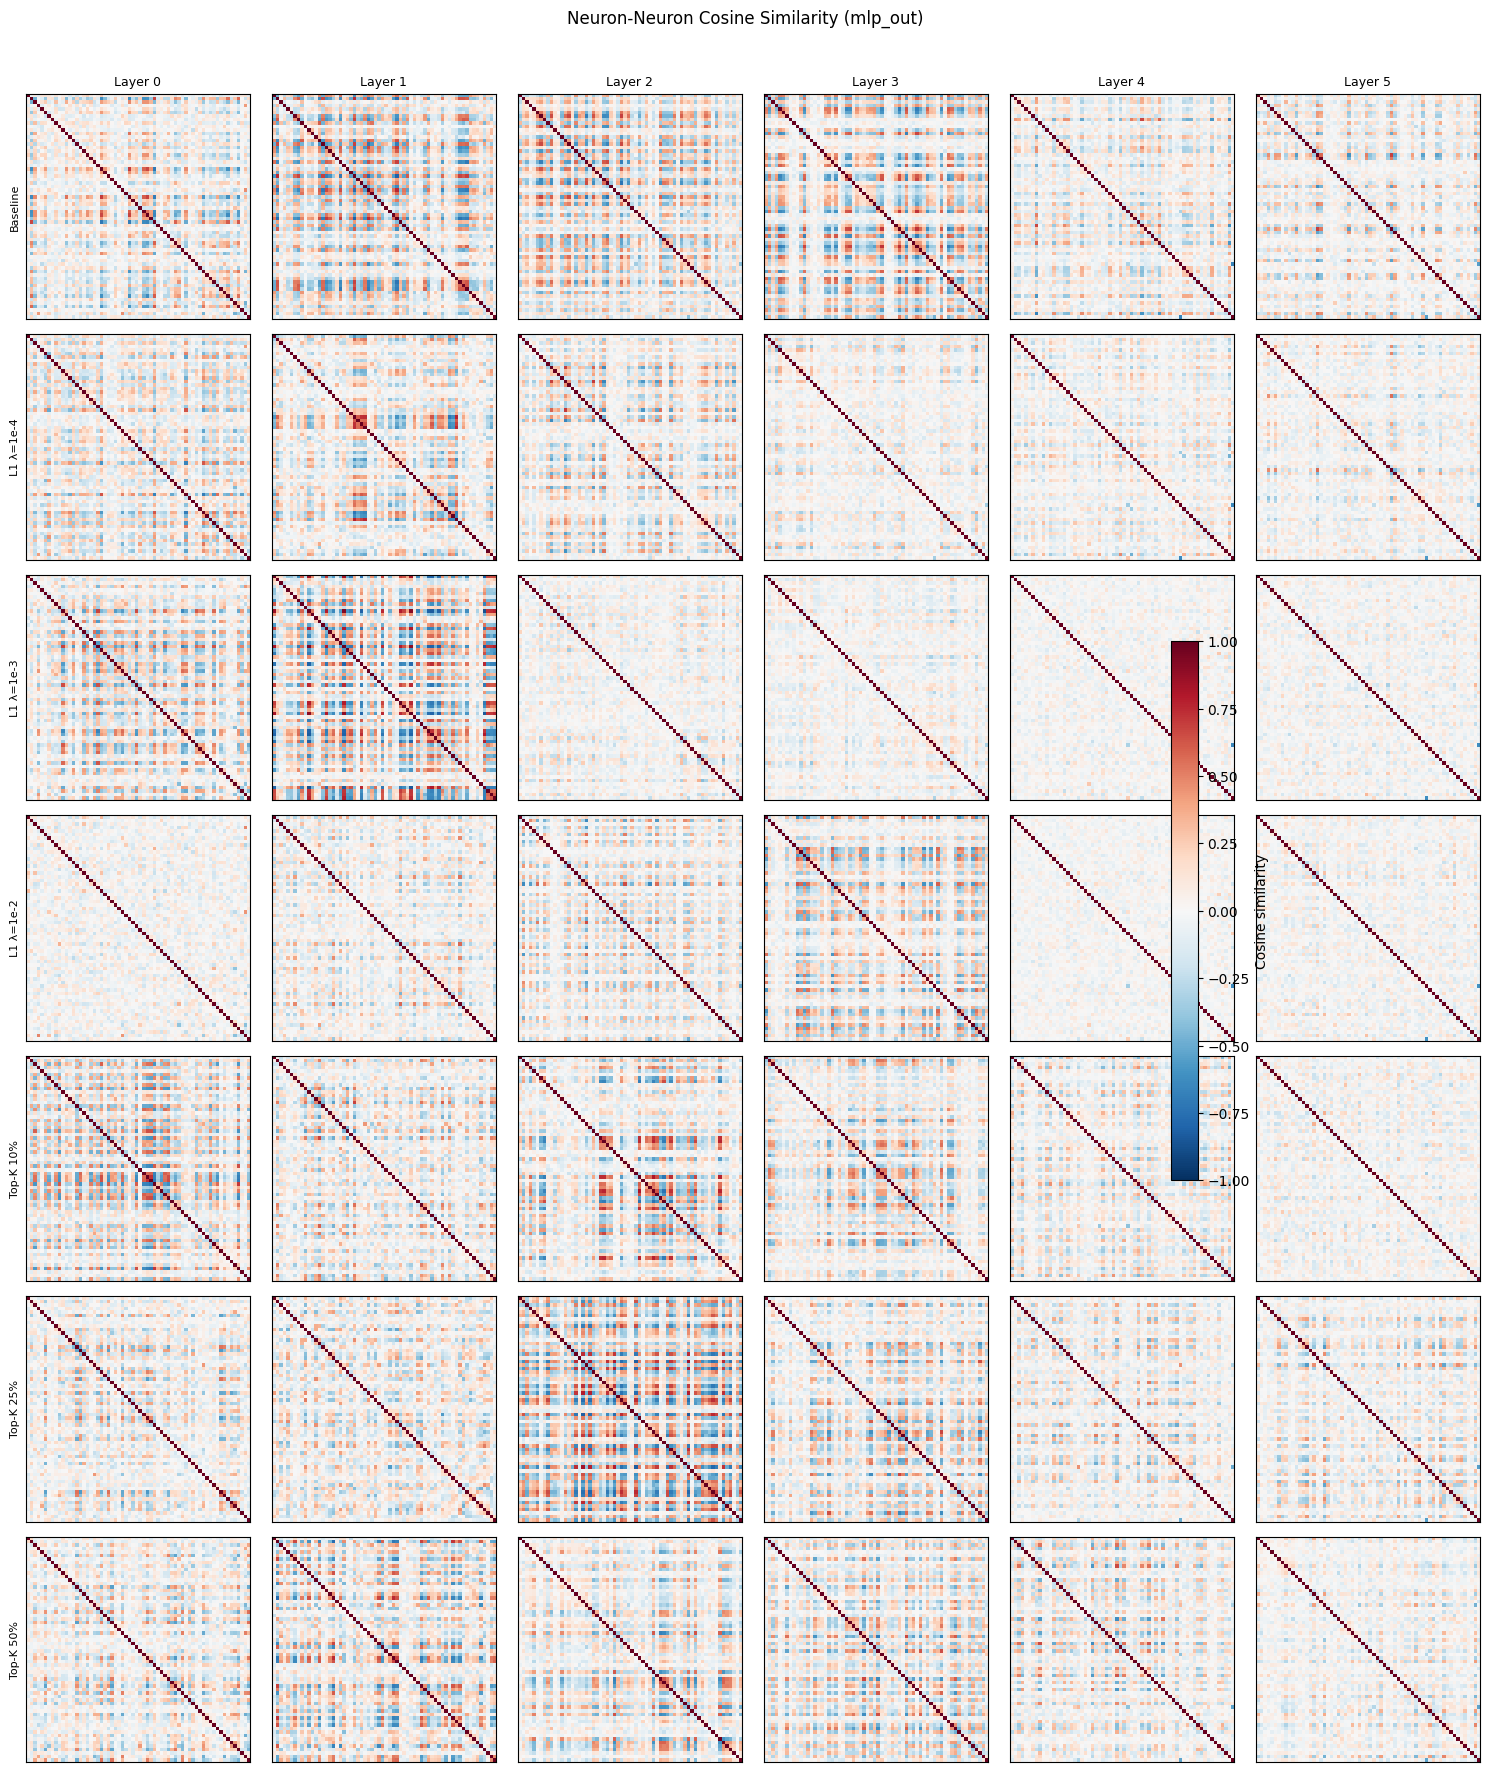

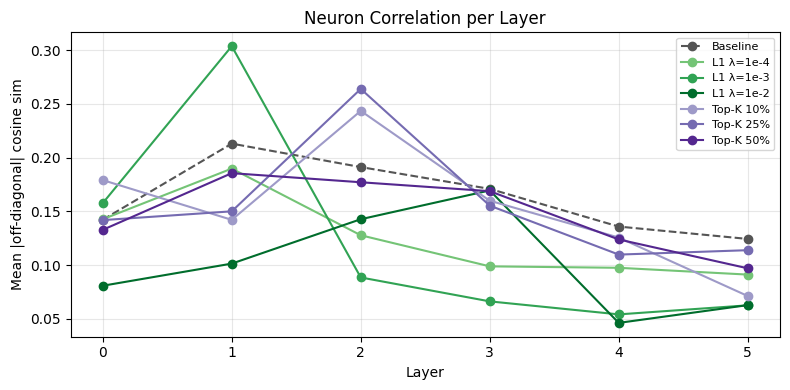

In [6]:
heatmap_runs = [r for r in AVAILABLE_RUNS if has_artifact(r, "cosine_sim_heatmaps.npz")]

if not heatmap_runs:
    print("No cosine_sim_heatmaps.npz found yet.")
else:
    sim_data = {}
    mean_off_diag_data = {}

    for run_name in heatmap_runs:
        npz = load_npz(run_name, "cosine_sim_heatmaps.npz")
        sim_data[run_name] = {int(k.split("_")[1]): npz[k] for k in npz.files}
        mods = {}
        for layer_idx, mat in sim_data[run_name].items():
            mask = ~np.eye(mat.shape[0], dtype=bool)
            mods[layer_idx] = float(np.abs(mat[mask]).mean())
        mean_off_diag_data[run_name] = mods

    # Grid
    n_runs = len(heatmap_runs)
    fig, axes = plt.subplots(n_runs, N_LAYERS, figsize=(N_LAYERS * 2.5, n_runs * 2.5), squeeze=False)
    for row_idx, run_name in enumerate(heatmap_runs):
        for col_idx in range(N_LAYERS):
            ax = axes[row_idx][col_idx]
            if col_idx not in sim_data[run_name]:
                ax.axis("off")
                continue
            mat = sim_data[run_name][col_idx]
            step = max(1, mat.shape[0] // 64)
            im = ax.imshow(mat[::step, ::step], vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
            if col_idx == 0:
                ax.set_ylabel(RUN_LABELS[run_name], fontsize=8)
            if row_idx == 0:
                ax.set_title(f"Layer {col_idx}", fontsize=9)
            ax.set_xticks([])
            ax.set_yticks([])
    fig.suptitle("Neuron-Neuron Cosine Similarity (mlp_out)", fontsize=12, y=1.01)
    plt.colorbar(im, ax=axes, shrink=0.4, label="Cosine similarity")
    plt.tight_layout()
    plt.show()

    # Mean off-diagonal line chart
    fig, ax = plt.subplots(figsize=(8, 4))
    for run_name in heatmap_runs:
        vals = [mean_off_diag_data[run_name].get(l, 0) for l in range(N_LAYERS)]
        ax.plot(range(N_LAYERS), vals, marker="o",
                label=RUN_LABELS[run_name], color=RUN_COLORS[run_name],
                linestyle=RUN_LINESTYLES[run_name])
    ax.set_xlabel("Layer")
    ax.set_ylabel("Mean |off-diagonal| cosine sim")
    ax.set_title("Neuron Correlation per Layer")
    ax.set_xticks(range(N_LAYERS))
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 6. Top-k Activating Contexts per Neuron

Do sparse neurons become more monosemantic — consistently activating on a narrower set of contexts?

In [7]:
topk_runs = [r for r in AVAILABLE_RUNS if has_artifact(r, "topk_contexts.json")]
topk_data = {r: load_json(r, "topk_contexts.json") for r in topk_runs}
print(f"Loaded top-k contexts for {len(topk_runs)} runs")

Loaded top-k contexts for 7 runs


In [8]:
def show_neuron_contexts(run_name, layer, neuron, top_n=5):
    label = RUN_LABELS.get(run_name, run_name)
    entries = topk_data[run_name].get(str(layer), {}).get(str(neuron), [])
    if not entries:
        print(f"No data for {label} layer={layer} neuron={neuron}")
        return
    print(f"\n{'='*60}")
    print(f"Run: {label}  |  Layer: {layer}  |  Neuron: {neuron}")
    print(f"{'='*60}")
    for entry in entries[:top_n]:
        print(f"  Rank {entry['rank']}  activation={entry['activation']:+.4f}")
        print(f"  Context: {entry['context_text'][:200]!r}")
        print()


# Example: compare neuron 0, layer 3 across runs
for run_name in topk_runs:
    show_neuron_contexts(run_name, layer=3, neuron=0, top_n=3)


Run: Baseline  |  Layer: 3  |  Neuron: 0
  Rank 0  activation=+0.8936
  Context: 'Once upon a time, there was a little bunny named Snowy. Snowy was very white and fluffy. She lived in a big field with her family and friends. Snowy loved to play and hop around in the sunshine.\n\nOne '

  Rank 1  activation=-0.8689
  Context: 'Once upon a time, there was a robot that did many things. It included modest tasks such as cleaning and helping around the house. One day, the robot was faced with a challenge that it could not solve.'

  Rank 2  activation=+0.8423
  Context: "Once upon a time there was a cheerful little girl named Jane. One day when she was out in the garden, she found a skull. She thought it was strange, but it wasn't too scary. She showed it to her mommy"


Run: L1 λ=1e-4  |  Layer: 3  |  Neuron: 0
  Rank 0  activation=+0.8974
  Context: 'Once upon a time, there was a little bunny named Snowy. Snowy was very white and fluffy. She lived in a big field with her family and friend

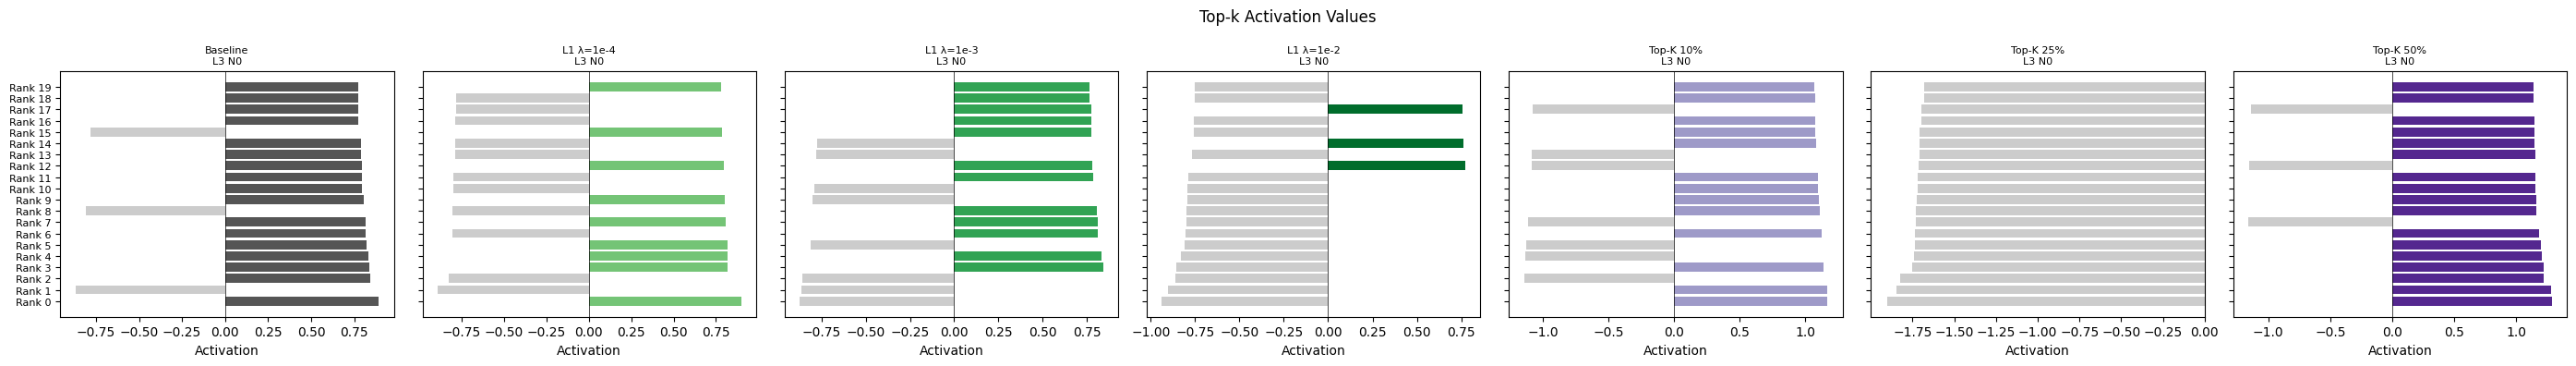

In [9]:
# Activation distribution for a given layer/neuron across runs
LAYER = 3
NEURON = 0

n = len(topk_runs)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=True)
if n == 1:
    axes = [axes]

for ax, run_name in zip(axes, topk_runs):
    entries = topk_data[run_name].get(str(LAYER), {}).get(str(NEURON), [])
    acts = [e["activation"] for e in entries]
    if acts:
        colors = [RUN_COLORS[run_name] if a >= 0 else "#cccccc" for a in acts]
        ax.barh(range(len(acts)), acts, color=colors)
        ax.set_yticks(range(len(acts)))
        ax.set_yticklabels([f"Rank {e['rank']}" for e in entries], fontsize=8)
    ax.set_xlabel("Activation")
    ax.set_title(f"{RUN_LABELS[run_name]}\nL{LAYER} N{NEURON}", fontsize=8)
    ax.axvline(0, color="k", linewidth=0.5)

plt.suptitle("Top-k Activation Values", fontsize=12)
plt.tight_layout()
plt.show()

## 7. Linear Probe Results (POS Tags)

Does sparsity help or hurt the quality of learned representations? A linear probe for POS tags measures how much syntactic information is linearly decodable from mlp_out.

In [10]:
probe_runs = [r for r in AVAILABLE_RUNS if has_artifact(r, "probe_results.json")]

if not probe_runs:
    print("No probe_results.json found yet.")
else:
    probe_data = {r: load_json(r, "probe_results.json") for r in probe_runs}

    rows = []
    for run_name in probe_runs:
        d = probe_data[run_name]
        for layer_idx in range(N_LAYERS):
            key = str(layer_idx)
            if key in d:
                rows.append({
                    "Run": RUN_LABELS[run_name],
                    "Layer": layer_idx,
                    "Accuracy": d[key]["accuracy"],
                    "Macro F1": d[key]["macro_f1"],
                })
    display(pd.DataFrame(rows).to_string(index=False))

'      Run  Layer  Accuracy  Macro F1\n Baseline      0  0.962109  0.844514\n Baseline      1  0.964257  0.849474\n Baseline      2  0.951764  0.852369\n Baseline      3  0.923423  0.831466\n Baseline      4  0.893561  0.798604\n Baseline      5  0.864247  0.774944\nL1 λ=1e-4      0  0.962043  0.846781\nL1 λ=1e-4      1  0.964084  0.848958\nL1 λ=1e-4      2  0.952395  0.851090\nL1 λ=1e-4      3  0.924253  0.830706\nL1 λ=1e-4      4  0.894070  0.799478\nL1 λ=1e-4      5  0.863402  0.775376\nL1 λ=1e-3      0  0.962109  0.844518\nL1 λ=1e-3      1  0.964390  0.848713\nL1 λ=1e-3      2  0.952818  0.849499\nL1 λ=1e-3      3  0.923199  0.835652\nL1 λ=1e-3      4  0.892588  0.800684\nL1 λ=1e-3      5  0.865999  0.774882\nL1 λ=1e-2      0  0.961931  0.846500\nL1 λ=1e-2      1  0.964685  0.849937\nL1 λ=1e-2      2  0.952935  0.854257\nL1 λ=1e-2      3  0.922706  0.832740\nL1 λ=1e-2      4  0.892415  0.800791\nL1 λ=1e-2      5  0.865907  0.773665\nTop-K 10%      0  0.958591  0.839168\nTop-K 10%  

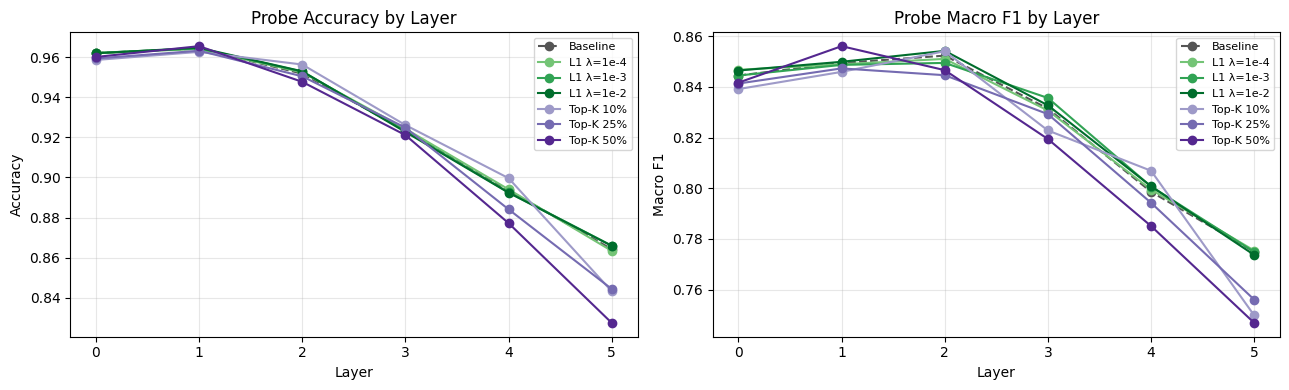

In [11]:
if probe_runs:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for run_name in probe_runs:
        d = probe_data[run_name]
        layers, accs, f1s = [], [], []
        for layer_idx in range(N_LAYERS):
            key = str(layer_idx)
            if key in d:
                layers.append(layer_idx)
                accs.append(d[key]["accuracy"])
                f1s.append(d[key]["macro_f1"])
        kw = dict(marker="o", label=RUN_LABELS[run_name],
                  color=RUN_COLORS[run_name], linestyle=RUN_LINESTYLES[run_name])
        axes[0].plot(layers, accs, **kw)
        axes[1].plot(layers, f1s, **kw)

    for ax, title, ylabel in zip(
        axes,
        ["Probe Accuracy by Layer", "Probe Macro F1 by Layer"],
        ["Accuracy", "Macro F1"],
    ):
        ax.set_xlabel("Layer")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.set_xticks(range(N_LAYERS))
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

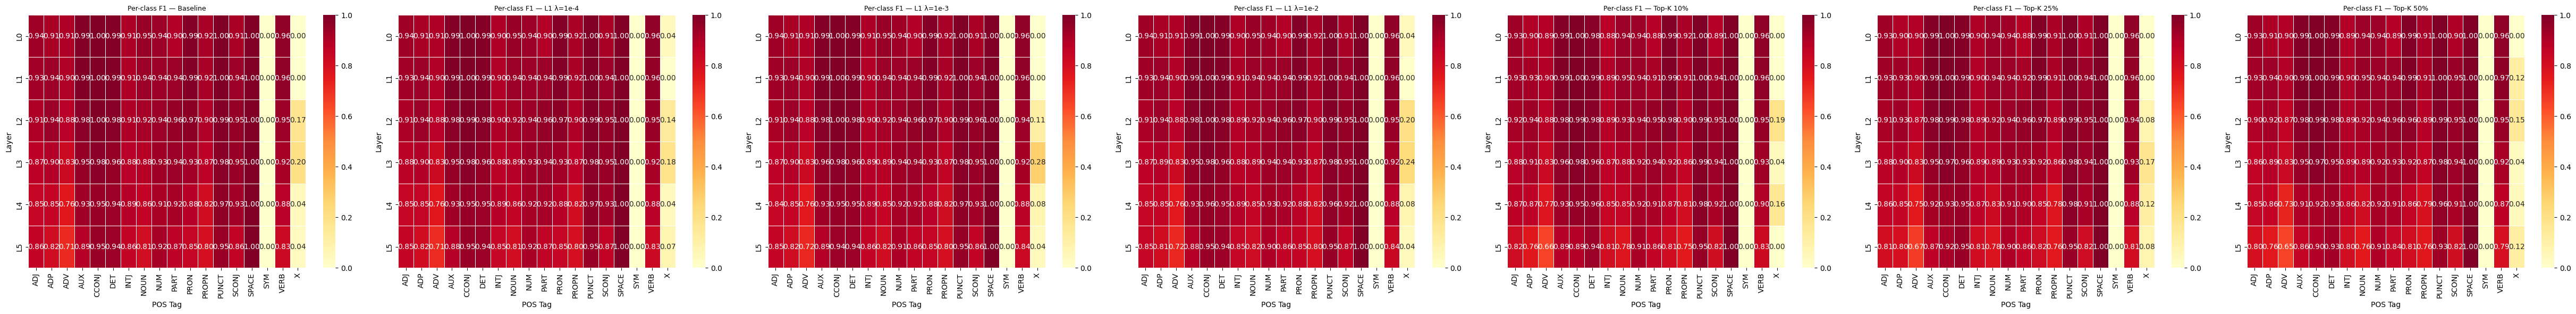

In [12]:
if probe_runs:
    n = len(probe_runs)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 6), squeeze=False)

    for col_idx, run_name in enumerate(probe_runs):
        ax = axes[0][col_idx]
        d = probe_data[run_name]
        label_names = d.get("label_names", [])
        mat = np.zeros((N_LAYERS, len(label_names)))
        for layer_idx in range(N_LAYERS):
            key = str(layer_idx)
            if key in d:
                per_class = d[key].get("per_class_f1", {})
                for j, tag in enumerate(label_names):
                    mat[layer_idx, j] = per_class.get(tag, 0.0)
        sns.heatmap(
            mat, ax=ax,
            xticklabels=label_names,
            yticklabels=[f"L{i}" for i in range(N_LAYERS)],
            vmin=0, vmax=1, cmap="YlOrRd",
            annot=True, fmt=".2f", linewidths=0.5,
        )
        ax.set_title(f"Per-class F1 — {RUN_LABELS[run_name]}", fontsize=9)
        ax.set_xlabel("POS Tag")
        ax.set_ylabel("Layer")

    plt.tight_layout()
    plt.show()

## 8. Cross-metric Analysis

Figures suitable for publication. All use the 7 Expt 2 runs (baseline + L1 × 3 + Top-K × 3).

- **Figure 1** — Correlation vs. Polysemanticity scatter
- **Figure 3** — Perplexity vs. Polysemanticity trade-off
- **Figure 5** — Pareto frontier (perplexity vs. interpretability)
- **Figure 6** — Metric correlation heatmap

In [13]:
# ── Shared data loading for Figures 1, 3, 5, 6 ──────────────────────────────
import numpy as np

fig_runs = [r for r in AVAILABLE_RUNS
            if has_artifact(r, "polysemanticity.json")
            and has_artifact(r, "perplexity.json")]

summary = {}
for run_name in fig_runs:
    pplx  = load_json(run_name, "perplexity.json")
    poly  = load_json(run_name, "polysemanticity.json")
    spars = load_json(run_name, "sparsity.json") if has_artifact(run_name, "sparsity.json") else {}
    probe = load_json(run_name, "probe_results.json") if has_artifact(run_name, "probe_results.json") else {}
    util  = load_json(run_name, "neuron_utilization.json") if has_artifact(run_name, "neuron_utilization.json") else {}

    # Mean off-diagonal cosine sim across layers
    cosine_offdiag = None
    if has_artifact(run_name, "cosine_sim_heatmaps.npz"):
        npz = load_npz(run_name, "cosine_sim_heatmaps.npz")
        vals = []
        for k in npz.files:
            mat = npz[k]
            mask = ~np.eye(mat.shape[0], dtype=bool)
            vals.append(float(np.abs(mat[mask]).mean()))
        cosine_offdiag = float(np.mean(vals)) if vals else None

    # Mean probe macro-F1 across layers
    probe_f1 = None
    if probe:
        f1s = [probe[str(i)]["macro_f1"] for i in range(N_LAYERS) if str(i) in probe]
        probe_f1 = float(np.mean(f1s)) if f1s else None

    # Mean dead / always-on fraction  — keys are "layer_0", "layer_1", ...
    dead_frac = alwayson_frac = None
    if util:
        dead_vals  = [util[f"layer_{i}"]["frac_dead"]      for i in range(N_LAYERS) if f"layer_{i}" in util]
        alwon_vals = [util[f"layer_{i}"]["frac_always_on"] for i in range(N_LAYERS) if f"layer_{i}" in util]
        dead_frac     = float(np.mean(dead_vals))  if dead_vals  else None
        alwayson_frac = float(np.mean(alwon_vals)) if alwon_vals else None

    summary[run_name] = {
        "label":          RUN_LABELS[run_name],
        "color":          RUN_COLORS[run_name],
        "perplexity":     pplx["perplexity"],
        "polysemanticity":poly["mean"],
        "sparsity":       spars.get("mean"),
        "cosine_offdiag": cosine_offdiag,
        "probe_f1":       probe_f1,
        "dead_frac":      dead_frac,
        "alwayson_frac":  alwayson_frac,
    }

print(f"Loaded summary for {len(summary)} runs")
for r, s in summary.items():
    print(f"  {s['label']:20s}  pplx={s['perplexity']:.2f}  "
          f"poly={s['polysemanticity']:.3f}  "
          f"cosine={s['cosine_offdiag']:.3f}  "
          f"dead={s['dead_frac']:.3f}  alwayson={s['alwayson_frac']:.3f}")

Loaded summary for 7 runs
  Baseline              pplx=4.31  poly=4.359  cosine=0.163  dead=0.000  alwayson=0.251
  L1 λ=1e-4             pplx=4.31  poly=4.504  cosine=0.125  dead=0.000  alwayson=0.223
  L1 λ=1e-3             pplx=4.31  poly=4.729  cosine=0.122  dead=0.000  alwayson=0.179
  L1 λ=1e-2             pplx=4.31  poly=5.056  cosine=0.101  dead=0.000  alwayson=0.094
  Top-K 10%             pplx=4.44  poly=3.694  cosine=0.154  dead=0.009  alwayson=0.000
  Top-K 25%             pplx=4.42  poly=4.039  cosine=0.156  dead=0.002  alwayson=0.000
  Top-K 50%             pplx=4.40  poly=4.267  cosine=0.147  dead=0.000  alwayson=0.000


### Figure 1 — Neuron Correlation vs. Polysemanticity

Each point is one run. X-axis: mean |off-diagonal| cosine similarity of mlp_out neurons (higher = more correlated/entangled). Y-axis: mean per-neuron token-type entropy (higher = more polysemantic).

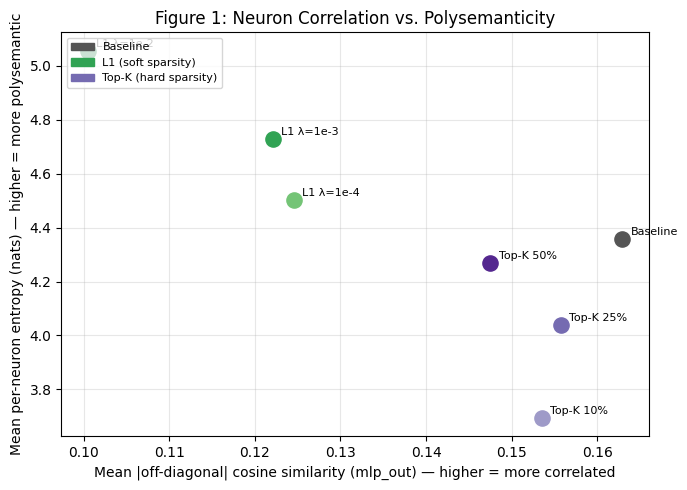

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))

for run_name, s in summary.items():
    if s["cosine_offdiag"] is None:
        continue
    ax.scatter(s["cosine_offdiag"], s["polysemanticity"],
               color=s["color"], s=120, zorder=3)
    ax.annotate(s["label"],
                xy=(s["cosine_offdiag"], s["polysemanticity"]),
                xytext=(6, 3), textcoords="offset points", fontsize=8)

ax.set_xlabel("Mean |off-diagonal| cosine similarity (mlp_out) — higher = more correlated")
ax.set_ylabel("Mean per-neuron entropy (nats) — higher = more polysemantic")
ax.set_title("Figure 1: Neuron Correlation vs. Polysemanticity")
ax.grid(alpha=0.3)

import matplotlib.patches as mpatches
patches = [
    mpatches.Patch(color="#555555", label="Baseline"),
    mpatches.Patch(color="#31a354", label="L1 (soft sparsity)"),
    mpatches.Patch(color="#756bb1", label="Top-K (hard sparsity)"),
]
ax.legend(handles=patches, fontsize=8, loc="upper left")
plt.tight_layout()
plt.savefig("../figures/fig1_correlation_vs_polysemanticity.jpg", dpi=300, bbox_inches="tight")
plt.show()

### Figure 3 — Perplexity vs. Polysemanticity Trade-off

Each point is one run. Bottom-left is ideal: low perplexity (good LM) and low polysemanticity (interpretable neurons).

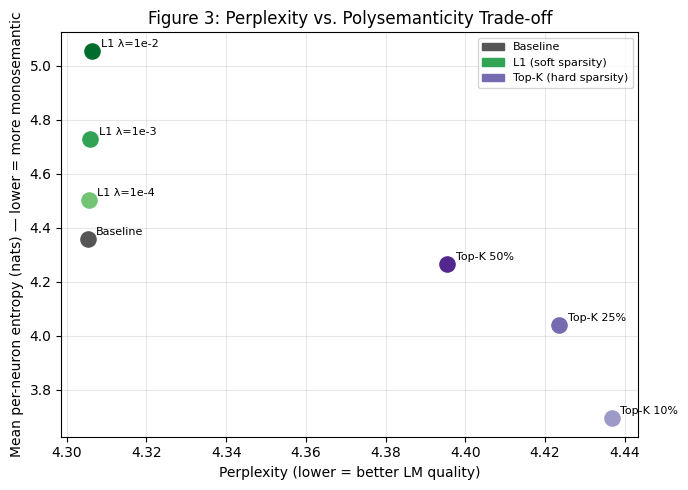

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))

for run_name, s in summary.items():
    ax.scatter(s["perplexity"], s["polysemanticity"],
               color=s["color"], s=120, zorder=3)
    ax.annotate(s["label"],
                xy=(s["perplexity"], s["polysemanticity"]),
                xytext=(6, 3), textcoords="offset points", fontsize=8)

ax.set_xlabel("Perplexity (lower = better LM quality)")
ax.set_ylabel("Mean per-neuron entropy (nats) — lower = more monosemantic")
ax.set_title("Figure 3: Perplexity vs. Polysemanticity Trade-off")
ax.grid(alpha=0.3)

patches = [
    mpatches.Patch(color="#555555", label="Baseline"),
    mpatches.Patch(color="#31a354", label="L1 (soft sparsity)"),
    mpatches.Patch(color="#756bb1", label="Top-K (hard sparsity)"),
]
ax.legend(handles=patches, fontsize=8)
plt.tight_layout()
plt.savefig("../figures/fig3_perplexity_vs_polysemanticity.jpg", dpi=300, bbox_inches="tight")
plt.show()

### Figure 5 — Pareto Frontier: Perplexity vs. Interpretability

Interpretability score = −polysemanticity (negated so higher = more interpretable). Once SAE results are available, replace with SAE explained variance for a stronger metric.

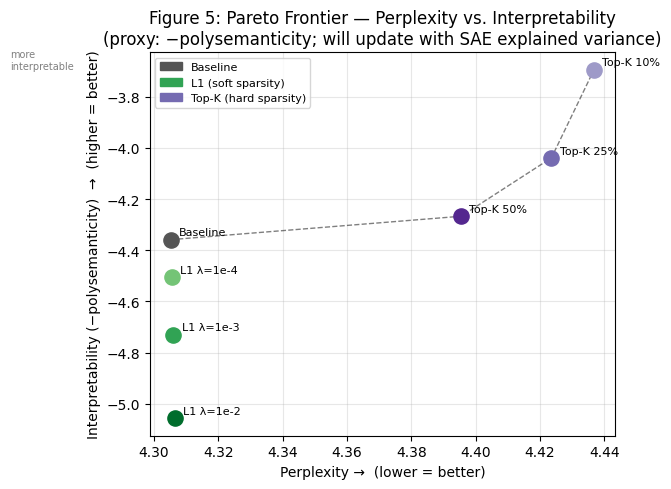

In [16]:
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(7, 5))

xs = [s["perplexity"]          for s in summary.values()]
ys = [-s["polysemanticity"]    for s in summary.values()]

for run_name, s in summary.items():
    interp = -s["polysemanticity"]
    ax.scatter(s["perplexity"], interp, color=s["color"], s=120, zorder=3)
    ax.annotate(s["label"],
                xy=(s["perplexity"], interp),
                xytext=(6, 3), textcoords="offset points", fontsize=8)

points = sorted(zip(xs, ys), key=lambda p: p[0])
pareto = []
best_y = -1e9
for px, py in points:
    if py >= best_y:
        pareto.append((px, py))
        best_y = py

if len(pareto) >= 2:
    pareto_xs, pareto_ys = zip(*pareto)
    ax.plot(pareto_xs, pareto_ys, color="black", linewidth=1,
            linestyle="--", alpha=0.5, label="Pareto front", zorder=2)

ax.annotate("", xy=(min(xs) - 0.1, max(ys) + 0.005),
            xytext=(min(xs) - 0.1, max(ys)),
            arrowprops=dict(arrowstyle="->", color="grey"))
ax.text(min(xs) - 0.05, max(ys) + 0.003, "more\ninterpretable", fontsize=7, color="grey")

ax.set_xlabel("Perplexity →  (lower = better)")
ax.set_ylabel("Interpretability (−polysemanticity)  →  (higher = better)")
ax.set_title("Figure 5: Pareto Frontier — Perplexity vs. Interpretability\n"
             "(proxy: −polysemanticity; will update with SAE explained variance)")
ax.grid(alpha=0.3)

patches = [
    mpatches.Patch(color="#555555", label="Baseline"),
    mpatches.Patch(color="#31a354", label="L1 (soft sparsity)"),
    mpatches.Patch(color="#756bb1", label="Top-K (hard sparsity)"),
]
ax.legend(handles=patches, fontsize=8)
plt.tight_layout()
plt.savefig("../figures/fig5_pareto_frontier.jpg", dpi=300, bbox_inches="tight")
plt.show()

### Figure 6 — Metric Correlation Heatmap

Pairwise Pearson correlations between all interpretability metrics across runs. Each run contributes one row (mean across layers). Strong correlations reveal which metrics are redundant vs. complementary.

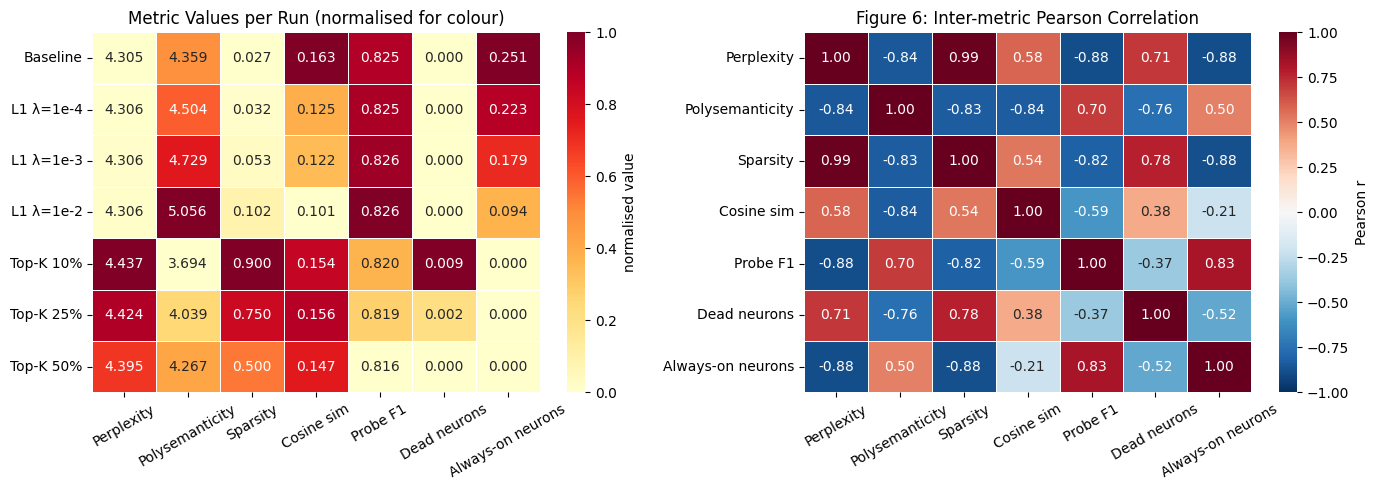


Full correlation matrix:


,Perplexity,Polysemanticity,Sparsity,Cosine sim,Probe F1,Dead neurons,Always-on neurons
Perplexity,1.00,-0.84,0.99,0.58,-0.88,0.71,-0.88
Polysemanticity,-0.84,1.00,-0.83,-0.84,0.70,-0.76,0.50
Sparsity,0.99,-0.83,1.00,0.54,-0.82,0.78,-0.88
Cosine sim,0.58,-0.84,0.54,1.00,-0.59,0.38,-0.21
Probe F1,-0.88,0.70,-0.82,-0.59,1.00,-0.37,0.83
Dead neurons,0.71,-0.76,0.78,0.38,-0.37,1.00,-0.52
Always-on neurons,-0.88,0.50,-0.88,-0.21,0.83,-0.52,1.00


In [17]:
metric_keys = {
    "Perplexity":        "perplexity",
    "Polysemanticity":   "polysemanticity",
    "Sparsity":          "sparsity",
    "Cosine sim":        "cosine_offdiag",
    "Probe F1":          "probe_f1",
    "Dead neurons":      "dead_frac",
    "Always-on neurons": "alwayson_frac",
}

rows = []
row_labels = []
for run_name, s in summary.items():
    vals = [s.get(v) for v in metric_keys.values()]
    if any(v is None for v in vals):
        continue
    rows.append(vals)
    row_labels.append(s["label"])

metric_df = pd.DataFrame(rows, columns=list(metric_keys.keys()), index=row_labels)
corr = metric_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metric_norm = (metric_df - metric_df.min()) / (metric_df.max() - metric_df.min() + 1e-10)
sns.heatmap(metric_norm, ax=axes[0], cmap="YlOrRd", annot=metric_df.round(3),
            fmt=".3f", linewidths=0.5, cbar_kws={"label": "normalised value"})
axes[0].set_title("Metric Values per Run (normalised for colour)")
axes[0].tick_params(axis="x", rotation=30)

sns.heatmap(corr, ax=axes[1], cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", linewidths=0.5,
            cbar_kws={"label": "Pearson r"})
axes[1].set_title("Figure 6: Inter-metric Pearson Correlation")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../figures/fig6_metric_correlation.jpg", dpi=300, bbox_inches="tight")
plt.show()

print("\nFull correlation matrix:")
display(corr.round(2))